<a href="https://colab.research.google.com/github/jamesriddellv/2026-Viromics-Practicals/blob/main/day3_Bioreactor_viruses_deep_dive_host_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Setup

In [5]:
# Clone the github repository to access the data and helper functions within colab.
!git clone https://github.com/jamesriddellv/2026-Viromics-Practicals.git

Cloning into '2026-Viromics-Practicals'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 65 (delta 29), reused 18 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 4.96 MiB | 12.83 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

# set fonts and ensure PDF text is editable:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'

In [7]:
# Set to the directory you uploaded the data to
import os

# Base directory for practicals
base_dir = './2026-Viromics-Practicals'

# Set data directory path
data_dir = os.path.join(base_dir, 'data')

# Verify the path exists
print("Data directory:", data_dir)
print("Files in data folder:", os.listdir(data_dir))

Data directory: ./2026-Viromics-Practicals/data
Files in data folder: ['cleaned_getmm_by_predicted_host.csv', '.DS_Store', 'alpha_diversity_metadata.csv', 'genomad_checkv_metadata.csv', 'contig_591846.fna', 'contig_591846_annotations.tsv', 'final_assignments.csv', 'contig_591846.gff', 'votu_relative_abundance.csv', 'genomad_checkv_dramv_metadata.csv', 'getmms_REV_5x_vOTUs_corrected_wide.tsv', 'metaT_sample_metadata.csv', 'cleaned_getmm_by_predicted_host_additional_predictions.csv', 'Host_prediction_to_genome_m90.csv']


# Host Prediction

Now that we know the vOTU community activity in catechin samples day 14-35 are significantly different, we want to which hosts these vOTUs infect. Given that catechin enriched for Pseudomonas_E, Clostridium, and JAGFXR01 MAGs, we'd expect changes in vOTU community activity were driven by vOTUs predicted to infect these MAGs, assuming these vOTUs and MAGs follow traditional predator-prey dynamics.

Here, we will load in vOTU abundances per-sample and virus-host predictions made with iPHoP.

[IPHoP](https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.3002083#pbio-3002083-g002) is a virus-host prediction tool that combines homology-based (BLAST, CRISPR) and alignment-free deep-learning methods. For this project, we used a custom iPHoP host database composed of 2,302 medium and high-quality MAGs recovered from these bioreactor samples and previous MAG recovery efforts in our study site. It turned out that 40% of the 900 active vOTUs had a host prediction, with 50% of those predictions being made with BLAST, suggesting a high number of active vOTUs were capable of integrating into their host genome.

We want to know (1) which vOTUs were most active in the community, and (2) who they infected. To visualize vOTU community activity by predicted hosts, we will merge iPHoP results to relative abundance by vOTU, then group by predicted host genus, summing the abundance of vOTUs predicted to infect the same host. For highly abundant vOTUs (>4% of all vOTU activity in a given set of sample replicates), we will plot them individually in a slightly different color to get a sense for how much these highly active vOTUs expressed compared to the rest of the community.

# Part 1: Who are the most active vOTUs between treatments and over time?

In [ ]:
# Load metaT GeTMM relative abundance table
file_name = 'getmms_REV_5x_vOTUs_corrected_wide.tsv'
path = '/'.join([data_dir, file_name])
df = pd.read_csv(path, sep='\t')
df.head()

,vOTU,STM_0716_E_M_E002,STM_0716_E_M_E003,STM_0716_E_M_E004,STM_0716_E_M_E025,STM_0716_E_M_E027,STM_0716_E_M_E033,STM_0716_E_M_E034,STM_0716_E_M_E035,STM_0716_E_M_E050,...,STM_0716_E_M_E064,STM_0716_E_M_E070,STM_0716_E_M_E071,STM_0716_E_M_E072,STM_0716_E_M_E121,STM_0716_E_M_E122,STM_0716_E_M_E123,STM_0716_E_M_E129,STM_0716_E_M_E130,STM_0716_E_M_E131
0,contig_1000294|provirus_2_36746,0.0,0.0,0.0,72.464003,0.00000,0.000000,0.000000,0.000000,11.604841,...,0.00000,0.000000,0.000000,0.000000,71.239766,5.254664,0.000000,0.000000,0.000000,0.000000
1,contig_1000563,0.0,0.0,0.0,48.863221,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,264.821441,142.841287,409.715377,172.501055,118.109324,123.695971
2,contig_1000567,0.0,0.0,0.0,130.730865,69.63963,31.846424,72.690802,35.164220,200.725731,...,31.41151,30.464602,18.219285,21.022699,176.074381,40.904563,122.369957,53.767472,58.008758,50.326227
3,contig_1000721,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,214.109537,48.431831,...,0.00000,0.000000,22.769334,0.000000,14.917165,25.698245,0.000000,0.852605,0.000000,0.000000
4,contig_1001917,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
# Load iPHoP host prediction table

file_name = 'Host_prediction_to_genome_m90.csv'
path = '/'.join([data_dir, file_name])
iphop_df = pd.read_csv(path)
iphop_df.head()

,Virus,Host genome,Host taxonomy,Main method,Confidence score,Additional methods
0,contig_1000262,RS_GCF_900167265.1,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Cl...,iPHoP-RF,92.8,NaN
1,contig_1000294|provirus_2_36746,RS_GCF_005938625.1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,blast,92.4,iPHoP-RF;73.50
2,contig_1000294|provirus_2_36746,RS_GCF_012986595.1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,blast,92.3,iPHoP-RF;59.20
3,contig_1000294|provirus_2_36746,RS_GCF_000633255.1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,blast,92.1,iPHoP-RF;80.00
4,contig_1000294|provirus_2_36746,RS_GCF_002890915.1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,iPHoP-RF,91.8,CRISPR;58.50


Take a look at the different columns in iphop_df: this is the genome-level output file.

'Virus': The vOTU contig name.

'Host genome': The MAG accession (if iPHoP standard database) or MAG name from custom added MAGs.

'Host taxonomy': The GTDB taxonomy from GTDB-classify.

'Main method': The main prediction module from iPHoP used to make the prediction (BLAST, CRISPR, iPHoP-RandomForest, RaFAH, etc.)

'Confidence score': iPHoP's composite score of all the tools, with a false discovery rate of less than 10%.

'Additional method': The method and confidence score of any additional tools that also made a host prediction.
There is also a genus-level output file, but we are specifically interested in matching these vOTUs to specific MAGs for downstream analysis.

We will skip the data wrangling for sake of time, but if you are curious how the iphop table and relative abundance tables were merged and filtered, check the code here: https://github.com/jamesriddellv/Grantham_Bioreactor/blob/main/03-predict-hosts/scripts/06-host-prediction-EDA.py

In [ ]:
# Load in the cleaned merged dataframe containing the relative abundance of vOTUs grouped per-treatment, per-timepoint, per-predicted host.
file_name = 'cleaned_getmm_by_predicted_host.csv'
path = '/'.join([data_dir, file_name])
clean_df = pd.read_csv(path)
clean_df.head()

,treatment,day,taxon_grouped,taxon_grouped_abundance,taxon_grouped_prop_abundance,color
0,catechin,7,Other,178.086001,0.013426,black
1,catechin,7,g__Clostridium,3649.791209,0.275167,#9E0B0F
2,catechin,7,g__Clostridium__contig_507316,216.432818,0.016317,#DC143C
3,catechin,7,g__Clostridium__contig_588865,474.995312,0.035811,#FF4500
4,catechin,7,g__Clostridium__contig_755337,379.058671,0.028578,#B22222


Here's a quick overview on the dataframe:
* Treatment: 'catechin' or 'unamended'
* day: The day of sampling (0, 7, 14, 21, and 35)
* taxon_grouped: The predicted host genus. MAGs <4% abundance in any single sample are grouped into "Other". vOTUs with especially high relative abundance in a single day (determined with rank abundance curve) are not grouped, and labeled with their host prediction pre-pended to the contig name, allowing us to plot them individually.
* taxon_grouped_abundance: the sum GeTMM of all vOTUs with the same genus prediction (except those especially abundant vOTUs) across all replicates.
* taxon_grouped_prop_abundance: proportion of all vOTU GeTMM relative abundance attributable to vOTUs in 'taxon_grouped' across replicates for a given treatment and day.
* color: the color to plot the values in. Especially abundant vOTUs plotted in different shades of the same color as the grouped vOTUs with the same predicted host.

In [ ]:
# Next, we will use the following function to visualize vOTU community abundance per day in each treatment.
# The graph we are going to produce is called a stacked area chart, but feel free to modify the code and visualize the data another way (stacked bar graph?) instead.
# The AI assist feature could be especially fun here to plot the data in different ways.

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# 1. Create a color mapping directly from clean_df
color_map = clean_df.drop_duplicates('taxon_grouped').set_index('taxon_grouped')['color']

# 2. Get all unique taxa across both treatments for a consistent color order & legend
all_taxa = sorted(clean_df['taxon_grouped'].dropna().unique())

# 3. Set up a 2-row, 1-column layout for plots with space on the right for the legend
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True, sharey=True)

treatments = ['unamended', 'catechin']

for ax, treatment in zip(axes, treatments):
    # Filter and pivot treatment data
    df_treatment = clean_df[clean_df['treatment'] == treatment]
    df_pivot = df_treatment.pivot(
        index='day',
        columns='taxon_grouped',
        values='taxon_grouped_prop_abundance'
    ).reindex(columns=all_taxa, fill_value=0) # Keep all taxa aligned

    # Map colors to current columns
    colors = [color_map.get(col, 'gray') for col in df_pivot.columns]

    # Plot stacked area chart
    ax.stackplot(
        df_pivot.index,
        df_pivot.T.values,
        colors=colors,
        alpha=0.7,
        edgecolor='none'
    )

    # Subplot styling
    ax.set_title(f"Treatment: {treatment.capitalize()}", fontsize=14, fontweight='bold')
    ax.set_ylabel("vOTU relative abundance", fontsize=11)
    ax.set_xticks([0, 7, 14, 21, 35])
    ax.grid(True, alpha=0.5)

axes[1].set_xlabel("Day", fontsize=14)

# 4. Build single shared legend elements
legend_elements = []
for col in all_taxa:
    label = f"{col}" if "contig" not in col else col

    patch = Patch(
        facecolor=color_map.get(col, 'gray'),
        label=label,
        alpha=0.7
    )
    legend_elements.append(patch)

# Reverse list order for legend alignment
legend_elements = legend_elements[::-1]

# 5. Attach shared legend to the side of the figure
fig.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(0.92, 0.5), # Positions legend outside the right edge
    fontsize=11,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Reserve right side space for legend
plt.show()

NameError: name 'clean_df' is not defined

## Reflection
Do these results reinforce or contradict the beta diversity results you found from day 2? Based on these results, which vOTUs (or groups of vOTUs) do you think were driving the vOTU community response to catechin days 14-35?

# Part 3: Leveraging iPHoP predictions and virus taxonomy to make additional host predictions
You may have noticed there were a lot of 'especially abundant' vOTUs that lacked a host prediction to an active MAG. This is quite unsatisfying--more than half the community activity is still unexplained! Without knowing who these vOTUs infect, it is much more difficult to interpret the ecology.

We can fill some of this in by using the "inactive MAG" host predictions from iPHoP, meaning predictions to MAGs not detected in our study.

After that, we'll use vConTACT3 to make some more predictions. How, you ask? Read on to find out--oh, the suspense!

# Reflection
So turns out many of these 'unassigned' vOTUs that made up more than 40% of vOTU community activity in unamended samples on day 14 wer predicted to infect Lachnoclostridium. If we look up Lachnoclostridium, we find that there is some discrepancies with its taxonomy, and is related to Clostridium. We do not detect and Lachnoclostridium MAGs, and so it's possible these vOTUs infect a Clostridium given how abundant they are, and how abundant Clostridium is in unamended samples, but of course this is only a hypothesis. However, it's an *informed* hypothesis that resolves a large amount of the unknown signal from the previous plot!

Let's keep going! We'll now use gene-sharing networks to make a few additional predictions.

If we check thes vOTU lengths for the remaining vOTUs, we can see that they're almost all quite short. Our intuition was that these vOTUs lacked sufficient genomic context for iPHoP to make a confident host prediction.

Yet, vConTACT3 may be able to get around these limitations, Even with a few genes, vConTACT3 is capable of clustering vOTUs at fine taxonomic resolution. If we happen to find these unassigned vOTU fragments in a unique cluster of vOTUs that all have the same host prediction, it's possible the unassigned vOTU also infects similar MAGs if we assume closely related vOTUs generally infect related MAGs.

In [ ]:
# Load in vConTACT3 data, isolate the unassigned vOTUs, then pull all vOTUs in the same genera and check host predictions

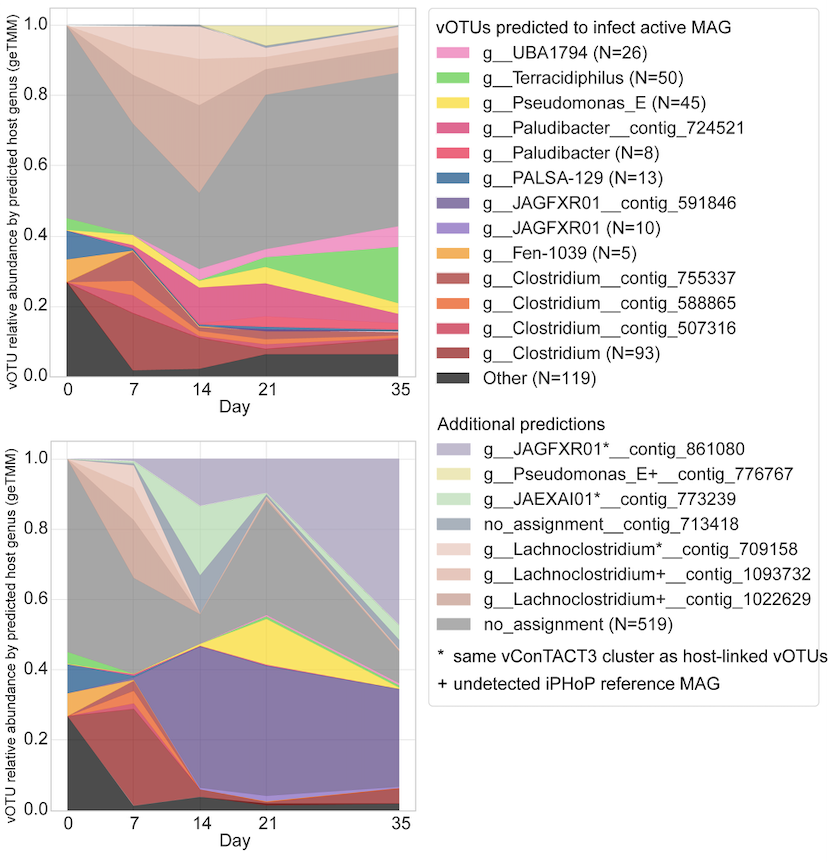

Reflection and critique: A few of these vOTUs that garnered high normalized relative abundance scores were very small viral fragments that were highly mapped.

What are potential outcomes if we recovered a longer contig of these vOTUs? What would you check to ensure the observed relative abundance is a real biological signal versus a technical artifact?

# Part 3: A closer look at the highly active vOTU predicted to infect the key catechin degrader JAGFXR01.

The previous study identified JAGFXR01, an uncultured *Bacillota*, as the most active catechin degrader based on relative expression of genes annotated to produce catechin-degrading enzymes.

Based on our analysis above, a single vOTU predicted to infect JAGFXR01 accounted for at least 40% of relative activity. However, with the data above, we still don't know anything about the virus lifestyle (obligately lytic, temperate, chronic infection?) or what genes were being actively transcribed (could have been mostly temperate phage genes).

Since this is potentially the major finding we want to report in the study, we want to build confidence in ourselves and for others that (1) this is actually a virus contig, and if possible, be able to say (2) what kind of virus it is, (3) what genes are being transcribed, (4) what is the basis of the virus-host prediction and can it be manually verified, and (5) how abundant is it relative to the host its predicted to infect? This requires going back into those datasets we generated with the suite of viromics tools, and now that we know what we're looking for, looking past the summary statistics and pulling out a specific virus contig.

### What kind of virus, and what genes are being transcribed?
To figure out what kind of virus this contig is, we can inspect the genome annotations

In [12]:
# Load the intermediate CSV file

# DRAMv output with additional columns from genomad annotations
# and a concatenated column of all annotations for each gene from each database.
file_name = "contig_591846_annotations.tsv"
path = '/'.join([data_dir, file_name])
df_genes = pd.read_csv(path, sep='\t')
df_genes.head()

,vOTU,length,topology,coordinates,n_genes,genetic_code,virus_score,fdr,n_hallmarks,marker_enrichment,...,vogdb_categories,heme_regulatory_motif_count,virsorter_category,auxiliary_score,is_transposon,amg_flags,annotation_accessions,annotation_description,evalue,concat_annotations
0,contig_591846,40862,No terminal repeats,NaN,63,11,0.9981,0.0018,17,63.3295,...,NaN,0.0,-,5.0,False,F,NaN,NaN,NaN,rpi:Rpic_4896 acriflavin resistance protein;;...
1,contig_591846,40862,No terminal repeats,NaN,63,11,0.9981,0.0018,17,63.3295,...,NaN,0.0,0,4.0,False,F,COG5377,"Phage-related protein, predicted endonuclease",3.893000e-09,bprl:CL2_29940 putative phage-type endonuclea...
2,contig_591846,40862,No terminal repeats,NaN,63,11,0.9981,0.0018,17,63.3295,...,Xu,0.0,1,1.0,False,PF,PF07083,NaN,3.337000e-44,ere:EUBREC_2126 hypothetical protein;YP_00222...
3,contig_591846,40862,No terminal repeats,NaN,63,11,0.9981,0.0018,17,63.3295,...,Xr,0.0,1,1.0,False,VF,PF03837;TIGR01913;COG3723,phage recombination protein Bet,3.745000e-36,cpas:Clopa_4307 phage recombination protein B...
4,contig_591846,40862,No terminal repeats,NaN,63,11,0.9981,0.0018,17,63.3295,...,Xu,0.0,1,1.0,False,F,PF16784,Putative HNHc nuclease,9.788000e-55,amt:Amet_2584 hypothetical protein;;Putative ...


In [21]:
df_genes.columns

Index(['vOTU', 'length', 'topology', 'coordinates', 'n_genes', 'genetic_code',
       'virus_score', 'fdr', 'n_hallmarks', 'marker_enrichment', 'taxonomy',
       'contig_length', 'provirus', 'proviral_length', 'gene_count',
       'viral_genes', 'host_genes', 'checkv_quality', 'miuvig_quality',
       'completeness', 'completeness_method', 'contamination', 'kmer_freq',
       'warnings', 'is_provirus_aggregated', 'Unnamed: 0', 'fasta',
       'gene_position', 'start_position', 'end_position', 'strandedness',
       'rank', 'kegg_genes_id', 'ko_id', 'kegg_hit', 'kegg_RBH',
       'kegg_identity', 'kegg_bitScore', 'kegg_eVal', 'viral_id', 'viral_hit',
       'viral_RBH', 'viral_identity', 'viral_bitScore', 'viral_eVal',
       'peptidase_id', 'peptidase_family', 'peptidase_hit', 'peptidase_RBH',
       'peptidase_identity', 'peptidase_bitScore', 'peptidase_eVal',
       'pfam_hits', 'cazy_ids', 'cazy_hits', 'cazy_subfam_ec', 'cazy_best_hit',
       'vogdb_id', 'vogdb_hits', 'vogdb_categ

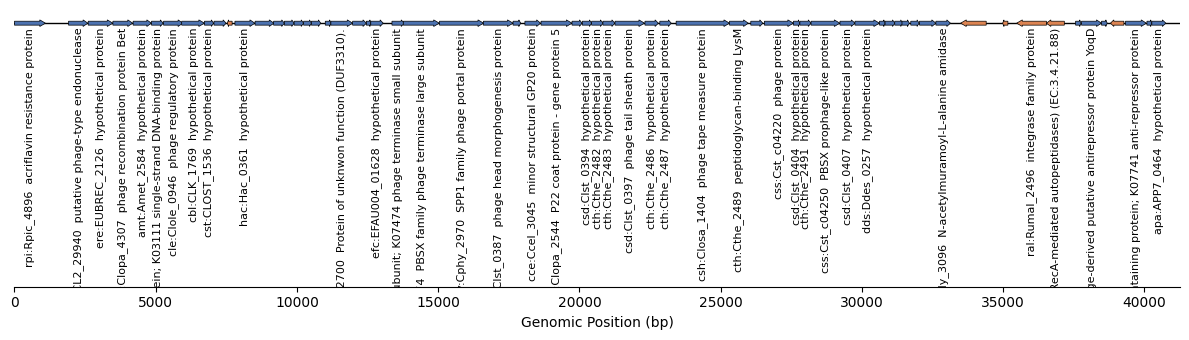

In [20]:

import matplotlib.patches as patches

# --- Choose which functional annotation database to label with ---
# Database options:
# "kegg_hit", "viral_hit", "peptidase_hit", "cazy_best_hit", "vogdb_hits"
# "annotation_description" (genomad)
# "concat_annotations" (all annotations per-gene concatenated into one string)
label_col = "kegg_hit"  #

genome_length = df_genes["end_position"].max() + 500  # Expand buffer slightly

fig, ax = plt.subplots(figsize=(12, 3.5))  # Increased height slightly for vertical labels

for _, row in df_genes.iterrows():
    start, end, strand = row["start_position"], row["end_position"], row["strandedness"]
    length = end - start
    color = "#4C72B0" if strand in ["+", 1] else "#DD8452"
    head_len = min(length * 0.25, 200)

    dx = length if strand in ["+", 1] else -length
    x_start = start if strand in ["+", 1] else end

    # 1. Draw Arrow
    arrow = patches.FancyArrow(
        x_start, 0, dx, 0,
        width=0.3, head_width=0.5, head_length=head_len,
        length_includes_head=True, color=color, ec="black", linewidth=0.5
    )
    ax.add_patch(arrow)

    # 2. Add Label Below (if column exists and value isn't empty/NaN)
    if label_col in row and pd.notna(row[label_col]):
        label_text = str(row[label_col])
        midpoint = start + (length / 2)  # Center text relative to the gene

        ax.text(
            x=midpoint,
            y=-0.35,  # Placed just below the arrow track
            s=label_text,
            rotation=90,
            ha="center",  # Horizontal center aligned with gene midpoint
            va="top",  # Top of the text anchored at y=-0.35 (grows downwards)
            fontsize=8,
            clip_on=True  # Keeps labels within plot bounds
        )

# Baseline genome track
ax.plot([0, genome_length], [0, 0], color="black", linewidth=1, zorder=0)

# Styling
ax.set_xlim(0, genome_length)
ax.set_ylim(-20.0, 1)  # Expanded y-lower limit to give vertical text room to fit
ax.set_yticks([])
ax.set_xlabel("Genomic Position (bp)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

##  The annotations always come out messy, so I've gone ahead and cleaned up the annotations based on the concatenated annotations so that it's easier to see them all together:

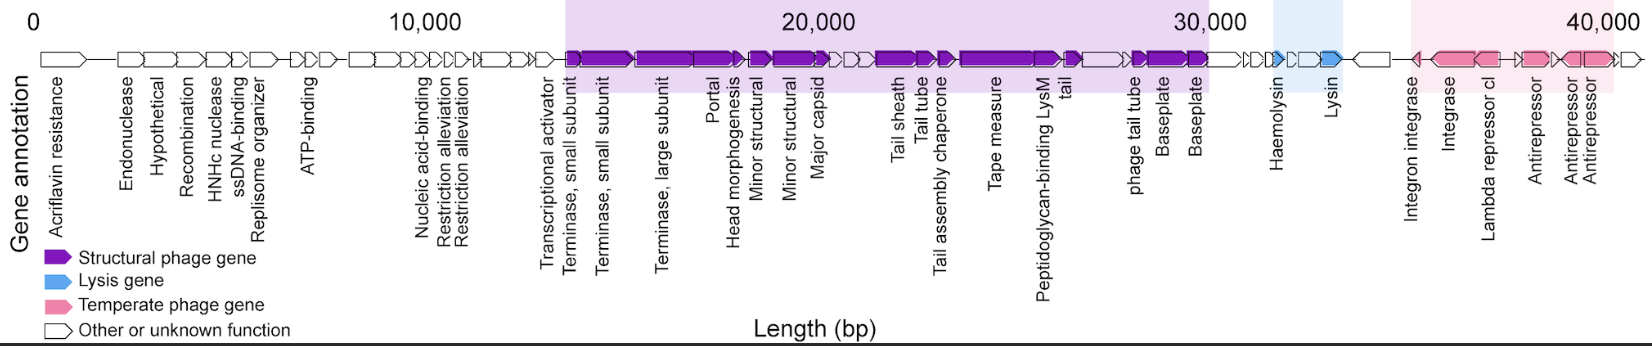

## Reflection:
1. Based on these annotations, what kind of virus do you think this is (i.e., obligately lytic, temperate)?
2. Find "contig_591846.fna" in the data directory, download it, and blast it against NCBI: https://blast.ncbi.nlm.nih.gov/Blast.cgi.

Have we seen similar viruses like this before? If yes, how similar (% identity)?


# For this next part, we will figure out how active this virus really is, and which parts of the genome are most highly expressed.

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from Bio import SeqIO
from BCBio import GFF
from dna_features_viewer import GraphicFeature, GraphicRecord

# --- 1. Load and Process Data ---

# Ridgeline Data
pileup_file = "/fs/ess/PAS1117/riddell26/Grantham_Bioreactor/02-get-relative-abundance/results/vOTU/read_mapping_metaT/pileup_data/combined_pileup.csv"
pileup_data = pd.read_csv(pileup_file)
pileup_data["sample"] = pileup_data["sample"].str.replace("_90FILTERED", "", regex=False)

metadata_file = "/fs/ess/PAS1117/riddell26/Grantham_Bioreactor/01-build-vOTU-database/data/sample_metadata.csv"
metadata = pd.read_csv(metadata_file)
metadata["sample"] = metadata["Sample"]

pileup_data = pd.merge(pileup_data, metadata, on="sample", how="left")
pileup_data["sample"] = pileup_data["treatment_day_replicate"]

# Filter for samples starting with 'catechin' (case-insensitive)
pileup_data = pileup_data[pileup_data["sample"].str.contains(r"^catechin", case=False, na=False)].copy()
pileup_data["day"] = pileup_data["day"].astype(str)

# BLAST Alignment Data
blast_file = "/fs/ess/PAS1117/riddell26/Grantham_Bioreactor/03-predict-hosts/results/contig_591846_STM_0716_E_M_E034_A_bin.10_blastn.txt"
blast_headers = ["qacc", "sacc", "pident", "length", "mismatch", "gapopen",
                 "qstart", "qend", "sstart", "send", "evalue", "bitscore"]
blast_data = pd.read_csv(blast_file, sep="\t", comment="#", names=blast_headers)

# Genome Data (FASTA and GFF)
wdir = "/fs/ess/PAS1117/riddell26/Grantham_Bioreactor/01-build-vOTU-database/results/vOTUs/JAGFXR01_vOTUs"
fasta_path = os.path.join(wdir, "contig_591846.fna")
gff_path = os.path.join(wdir, "contig_591846.gff")

# Determine Genome Length from FASTA
seq_record = next(SeqIO.parse(fasta_path, "fasta"))
genome_length = len(seq_record)

# Parse GFF Features
features = []
with open(gff_path) as handle:
    for rec in GFF.parse(handle):
        for feat in rec.features:
            if feat.type == "gene" or feat.type == "CDS":
                strand = 1 if feat.strand == 1 else -1
                color = "skyblue" if strand == 1 else "salmon"
                features.append(
                    GraphicFeature(
                        start=int(feat.location.start),
                        end=int(feat.location.end),
                        strand=strand,
                        color=color,
                        label=feat.qualifiers.get("Name", [""])[0]
                    )
                )

# --- 2. Create Plots with Subplots ---

fig, (ax_top, ax_mid, ax_bot) = plt.subplots(
    3, 1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 0.4, 1]}
)
plt.subplots_adjust(hspace=0.05)

# --- A. Ridgeline Plot (Top) ---
days = sorted(pileup_data["day"].unique())
max_cov = pileup_data["coverage"].max()
grid_values = [2000, 4000, 6000, 8000]

# Plot manual dashed gridlines and ridgelines per day
for idx, day_val in enumerate(reversed(days)):
    y_base = idx
    day_df = pileup_data[pileup_data["day"] == day_val].sort_values("position")

    # Custom Gridlines
    for gval in grid_values:
        rel_height = (gval / max_cov) * 0.9
        y_pos = y_base + rel_height
        ax_top.plot([0, genome_length], [y_pos, y_pos], color="gray", linestyle="--", alpha=0.5, zorder=1)

    # Ridgeline Fill and Border
    x = day_df["position"].values
    y_scaled = y_base + (day_df["coverage"].values / max_cov) * 0.9

    ax_top.fill_between(x, y_base, y_scaled, color="grey", alpha=0.3, zorder=2)
    ax_top.plot(x, y_scaled, color="black", linewidth=1, zorder=3)

ax_top.set_yticks(range(len(days)))
ax_top.set_yticklabels(reversed(days))
ax_top.set_ylabel("Time Point")
ax_top.set_xlim(0, genome_length)
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_top.spines['bottom'].set_visible(False)
ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# --- B. BLAST Alignment Plot (Middle) ---
for _, row in blast_data.iterrows():
    qstart, qend = min(row["qstart"], row["qend"]), max(row["qstart"], row["qend"])
    # Red bar alignment segment
    ax_mid.hlines(y=0, xmin=qstart, xmax=qend, colors="red", linewidth=6)
    # Black left border highlight
    ax_mid.hlines(y=0, xmin=qstart, xmax=qstart + 10, colors="black", linewidth=6)

ax_mid.set_ylim(-0.5, 0.5)
ax_mid.set_ylabel("Host Align", rotation=90, labelpad=15, va="center")
ax_mid.axis("off")

# --- C. Genome Plot (Bottom) ---
record = GraphicRecord(sequence_length=genome_length, features=features)
record.plot(ax=ax_bot, plot_sequence=False)

ax_bot.set_xlabel("Genomic Position (bp)")
ax_bot.spines['top'].set_visible(False)
ax_bot.spines['right'].set_visible(False)
ax_bot.spines['left'].set_visible(False)
ax_bot.set_yticks([])

plt.show()


ModuleNotFoundError: No module named 'Bio'

In [ ]:

# --- 3. Compute Unique Coverage ---

# Ensure start <= end
blast_data["start"] = blast_data[["qstart", "qend"]].min(axis=1)
blast_data["end"] = blast_data[["qstart", "qend"]].max(axis=1)

# Sort by start position
intervals = blast_data[["start", "end"]].sort_values("start").to_numpy()

# Merge overlapping intervals
merged_intervals = []
for start, end in intervals:
    if not merged_intervals or merged_intervals[-1][1] < start:
        merged_intervals.append([start, end])
    else:
        merged_intervals[-1][1] = max(merged_intervals[-1][1], end)

# Calculate total unique bases
total_bases = sum((end - start + 1) for start, end in merged_intervals)
percent_coverage = (total_bases / genome_length) * 100

print(f"Total Unique Bases Covered: {total_bases} bp")
print(f"Percent of Genome Covered: {percent_coverage:.2f}%")

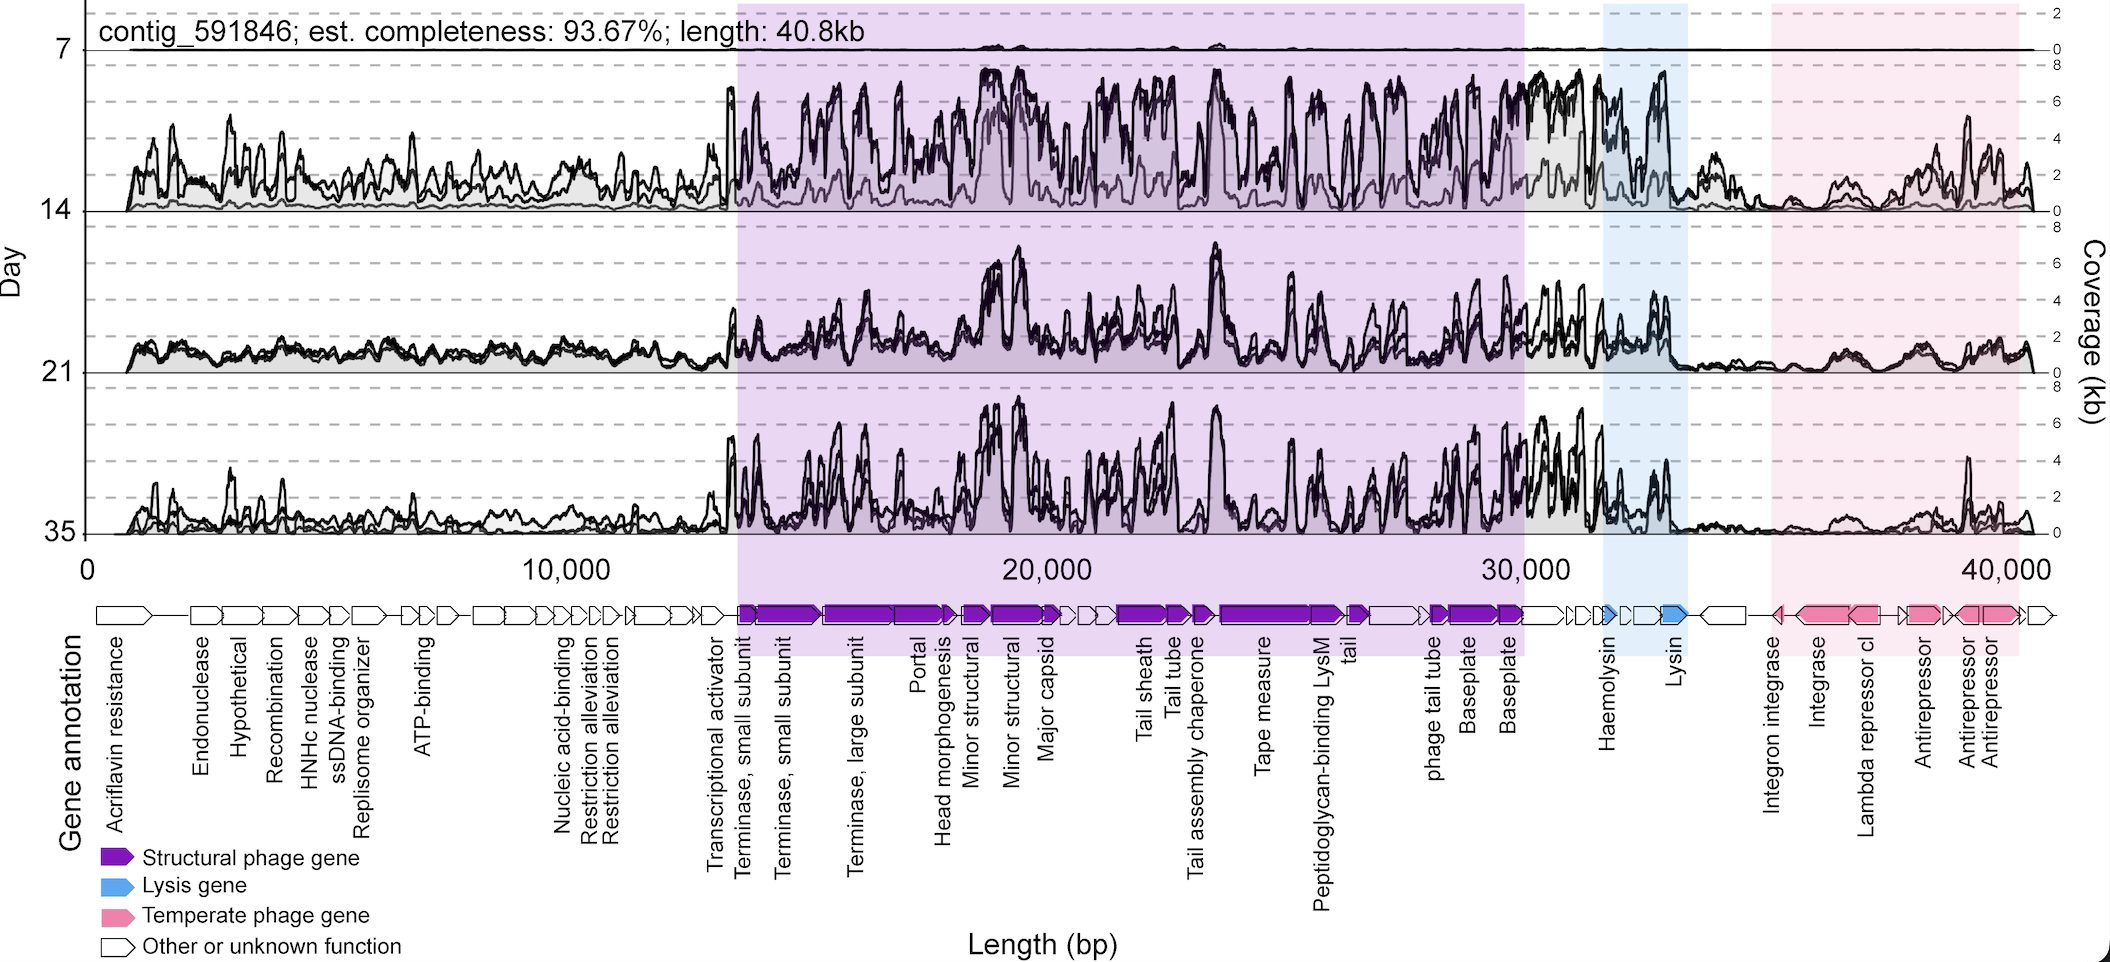